In [6]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [11]:
fake = pd.read_csv('Fake.csv')
true = pd.read_csv('True.csv')

# Assign labels
fake['label'] = 1   # Fake
true['label'] = 0   # Real

# Combine datasets
df = pd.concat([fake, true])

# Keep only text + label
df = df[['text', 'label']]

df.head()

,text,label
0,Donald Trump just couldn t wish all Americans ...,1
1,House Intelligence Committee Chairman Devin Nu...,1
2,"On Friday, it was revealed that former Milwauk...",1
3,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis used his annual Christmas Day mes...,1


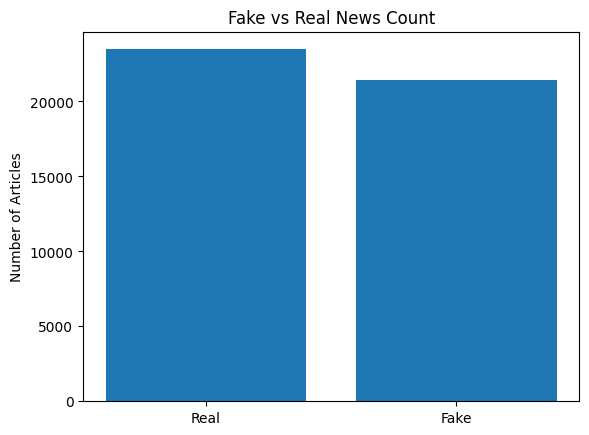

In [12]:
counts = df['label'].value_counts()

plt.bar(['Real', 'Fake'], counts)
plt.title("Fake vs Real News Count")
plt.ylabel("Number of Articles")
plt.show()

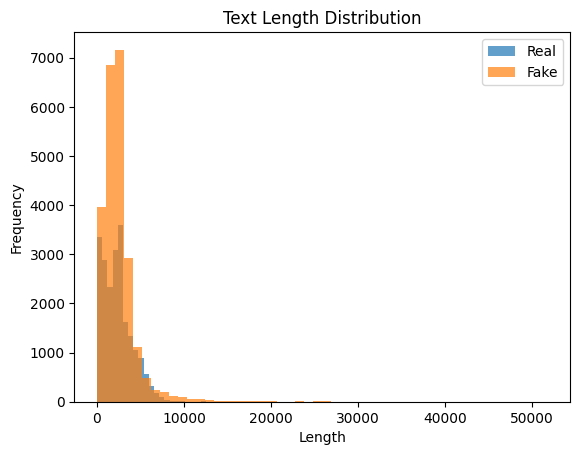

In [19]:
df['length'] = df['text'].apply(len)

plt.hist(df[df['label']==0]['length'], bins=50, alpha=0.7, label='Real')
plt.hist(df[df['label']==1]['length'], bins=50, alpha=0.7, label='Fake')

plt.legend()
plt.title("Text Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

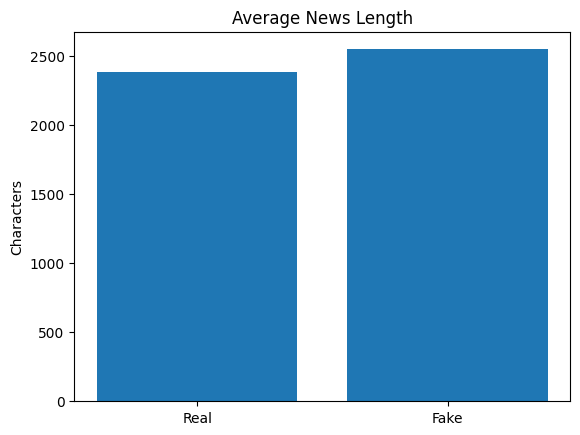

In [20]:
avg_lengths = df.groupby('label')['length'].mean()

plt.bar(['Real', 'Fake'], avg_lengths)
plt.title("Average News Length")
plt.ylabel("Characters")
plt.show()

In [21]:
def clean_text(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    return text

df['text'] = df['text'].apply(clean_text)

In [22]:
all_words = []

for text in df['text']:
    all_words.extend(text.split())

# Top 3000 words
common_words = Counter(all_words).most_common(3000)
vocab = [word for word, freq in common_words]

# Create fast lookup dictionary
word_index = {word: i for i, word in enumerate(vocab)}

def text_to_vector(text):
    vector = [0] * len(vocab)

    for word in text.split():
        if word in word_index:
            vector[word_index[word]] += 1

    return vector

# Convert all text into vectors
X = np.array([text_to_vector(text) for text in df['text']])
y = df['label'].values

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
# Models
lr = LogisticRegression(max_iter=1000)
rf = RandomForestClassifier()

# Train
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [25]:
lr_acc = accuracy_score(y_test, lr.predict(X_test))
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("Logistic Regression Accuracy:", lr_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.9975501113585746
Random Forest Accuracy: 0.9983296213808464


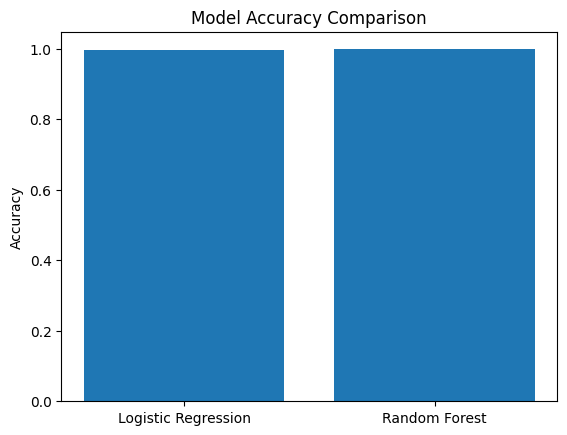

In [26]:
models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_acc, rf_acc]

plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [27]:
def predict_news(news_text):
    news_text = clean_text(news_text)
    vector = np.array(text_to_vector(news_text)).reshape(1, -1)

    prediction = lr.predict(vector)[0]
    confidence = lr.predict_proba(vector)[0][prediction]

    if prediction == 1:
        print(f"Fake News (Confidence: {confidence*100:.2f}%)")
    else:
        print(f"Real News (Confidence: {confidence*100:.2f}%)")

In [28]:
predict_news("Breaking: Government announces new policy today")
predict_news("Shocking! Celebrity caught in fake scandal")

Fake News (Confidence: 98.77%)
Fake News (Confidence: 99.22%)
